In [4]:
import time
import h5py

import numpy as np
import matplotlib.pyplot as plt
import sys

from chemrixs.average import Average
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
from chemrixs.utils import *
from pathlib import Path
%matplotlib widget 

140
setting up properties
dataset prop <functools.cached_property object at 0x7fa978874ad0>
dataset prop <functools.cached_property object at 0x7fa9786628d0>
dataset prop <functools.cached_property object at 0x7fa978759950>
dataset prop <functools.cached_property object at 0x7fa978fe1c90>
dataset prop <functools.cached_property object at 0x7fa97865e310>
dataset prop <functools.cached_property object at 0x7fa9786e1ad0>
dataset prop <functools.cached_property object at 0x7fa978624550>
dataset prop <functools.cached_property object at 0x7faacae2e190>
86
setting up properties
dataset prop <functools.cached_property object at 0x7fa978629d50>
dataset prop <functools.cached_property object at 0x7fa978650a90>
dataset prop <functools.cached_property object at 0x7fa978fd5610>
dataset prop <functools.cached_property object at 0x7fa97883eb10>
dataset prop <functools.cached_property object at 0x7fa978650410>
dataset prop <functools.cached_property object at 0x7fa9786505d0>
scanvariable is unkown, b

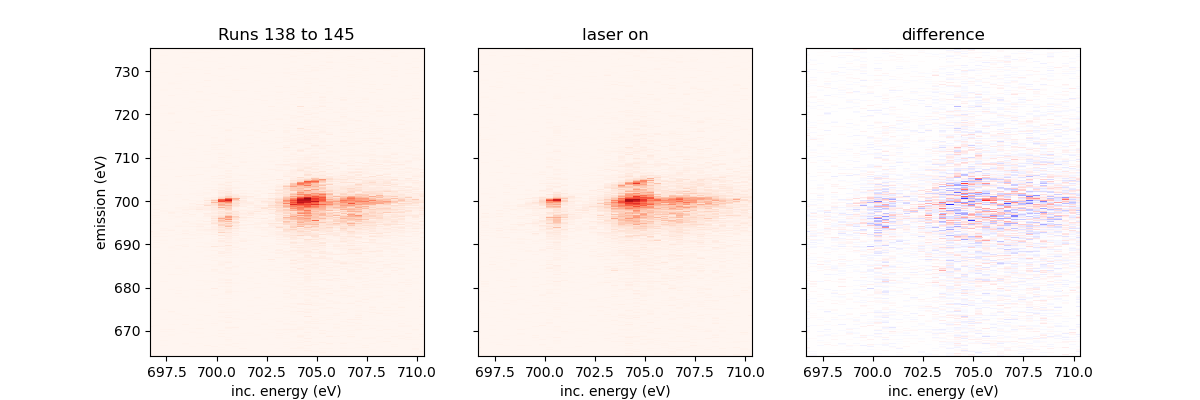

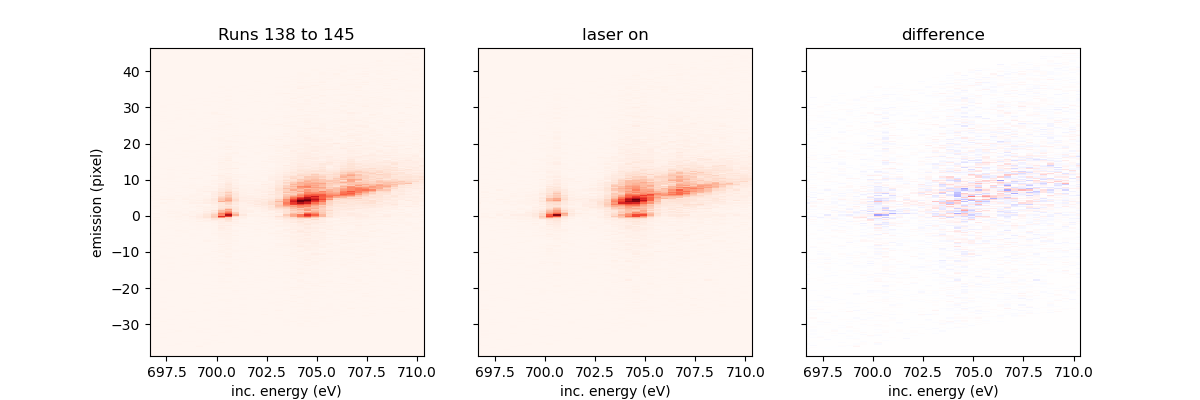

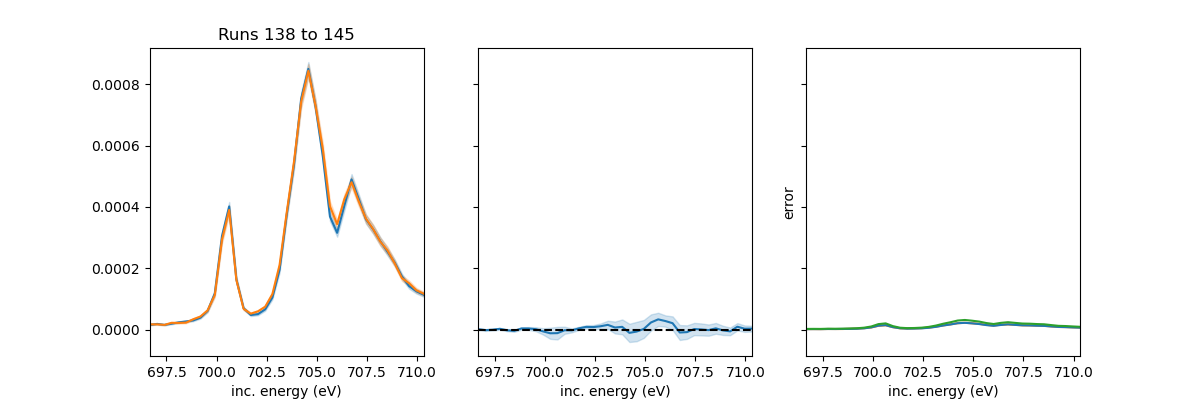

In [5]:
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'
exp = 'rix101331225'

bgrun = 86
runs = [178,179,180]
#[22,23,26,27,29,30,31,32]
runs = [112,114,115,116,117,118,119,120,121,122,123,127,129,138,139,140,141,145]
runs = [178,179,180,181,182,183,184,185,186]
runs = [138,139,140,141,145]

exp = 'rix101231825'


# fyaml = '../roi_inputTT.yml'
fyaml = '../roi_input.yml'

bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
bgyaml = '../BGroi_input.yml'

avg = Average(runs, proc_path = 'proc/Run', avg = 'mean', output_path = f'avg/{runs[0]}_to_{runs[-1]}.h5',
             raw_path = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run' , bgpath = bgname, fyaml=fyaml, bgyaml=bgyaml, 
             save= True,norm = True,scantype='mono_fly')

avg.plot_svls2D(figsize=(12,4),savefig=True,calibrated=True)
avg.plot_svls2D_ET(figsize=(12,4),savefig=True,ETstep=0.3)
avg.plot_svls1D(figsize=(12,4))



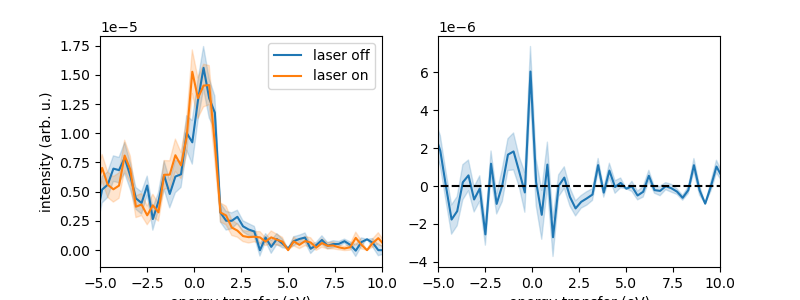

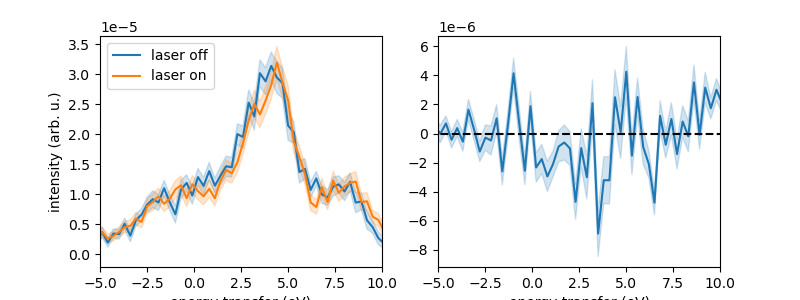

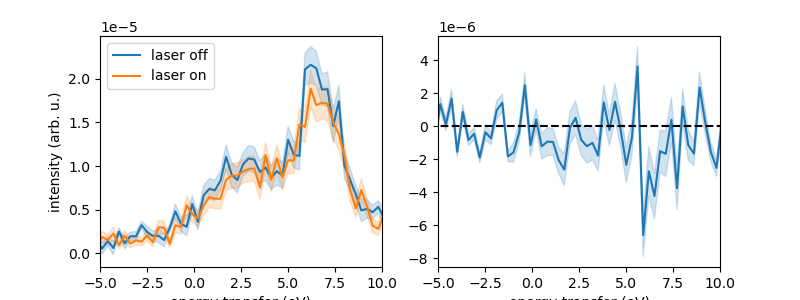

In [5]:

avg.plot_CIE(inc_energy=700.1,figsize=(8,3),xlim=[-5,10])
avg.plot_CIE(inc_energy=704.3,figsize=(8,3),xlim=[-5,10])
avg.plot_CIE(inc_energy=706.7,figsize=(8,3),xlim=[-5,10])

In [ ]:
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'
exp = 'rix101331225'

bgrun=6
run = 22

fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
fyaml = '../roi_inputTT.yml'
bgyaml = '../BGroi_input.yml'

data = SmallData(fname,fyaml)
proc = Reduced(fname,bgname,fyaml,bgyaml)
# bg = SmallData(bgname, bgyaml)

22
setting up properties
dataset prop <functools.cached_property object at 0x7f11d3869890>
dataset prop <functools.cached_property object at 0x7f11d3d7c190>
dataset prop <functools.cached_property object at 0x7f11ba4b2410>
dataset prop <functools.cached_property object at 0x7f11ba782010>
dataset prop <functools.cached_property object at 0x7f11d3d58510>
dataset prop <functools.cached_property object at 0x7f11d3d69410>
dataset prop <functools.cached_property object at 0x7f12d0524590>
dataset prop <functools.cached_property object at 0x7f12d0524450>
6
setting up properties
dataset prop <functools.cached_property object at 0x7f11bdc43c90>
dataset prop <functools.cached_property object at 0x7f11ba150e10>
dataset prop <functools.cached_property object at 0x7f11ba1531d0>
dataset prop <functools.cached_property object at 0x7f11d3d62d90>
dataset prop <functools.cached_property object at 0x7f11ba150f10>
dataset prop <functools.cached_property object at 0x7f11d3d43510>
scanvariable is unkown, bin


On the SVLS we filter out signal below a certain threshold. This leads to the pixel signal in individual frames either being 0 or in the range of few hundred ADU. With such a distribution a normal standard deviation will not give good results - the standard deviation will be much higher than the mean or the sum of values, so here is the result from a chatgpt prompt trying to get a meaningful uncertainty value for this case:

### Let's break this down with the assumption that:

1. **Binary Data with Varying Magnitudes**: Each shot has a probability ( $p_{\text{on}}$ ) of being "on," but when it is "on," the value ( $V_{\text{on}}$ ) is a random variable that follows some distribution. It might be Gaussian, uniform, or follow some other distribution, depending on your experiment.

2. **Mean and Variance of ( $V_{\text{on}}$ )**: Since ( $V_{\text{on}} $) varies from shot to shot, let’s define:

   * ( $V_{\text{on}}^{\text{mean}}$ ) as the expected value of ( $V_{\text{on}} $), i.e., the average value of the signal when it’s "on."
   * ($ \sigma_{V_{\text{on}}}^2 $) as the variance of ($ V_{\text{on}}$ ), which measures how much the value of ( $V_{\text{on}}$ ) fluctuates from shot to shot.

### Step-by-Step Error Propagation with Varying ( $V_{\text{on}} $):

#### 1. **Expected Value for Each Pixel (Mean)**:

The expected value ($ \mu $) of the signal for a single shot (pixel) can be expressed as the weighted average of the two possible outcomes (0 or ( $V_{\text{on}}$ )):

$\mu = p_{\text{on}} \cdot V_{\text{on}}^{\text{mean}}$

Where:

* ($ p_{\text{on}} $) is the probability of the signal being "on" (non-zero).
* ($ V_{\text{on}}^{\text{mean}} $) is the expected value of ( $V_{\text{on}}$ ).

#### 2. **Variance of the Signal**:

The variance for each individual pixel can be computed as the **variance of a mixture of two distributions** (since the pixel can either be "off" with value 0 or "on" with value ( $V_{\text{on}} $)):

[
$\sigma_{\text{signal}}^2 = p_{\text{on}} \left[ \sigma_{V_{\text{on}}}^2 + \left( V_{\text{on}}^{\text{mean}} \right)^2 \right]$
]

Where:

* ( $\sigma_{V_{\text{on}}}^2$ ) is the variance of ($ V_{\text{on}} $), the variability in the "on" signal.
* ($ \left( V_{\text{on}}^{\text{mean}} \right)^2 $) is the square of the mean of ($ V_{\text{on}}$ ), accounting for the average "on" value.

This accounts for both the inherent variability in ($ V_{\text{on}} $) (its own variance) and the **mean squared value** of ($V_{\text{on}}$ ).

#### 3. **Error Propagation for the Mean (Over ( N ) Shots)**:

Now, let’s propagate the uncertainty over ( N ) shots. The standard error of the mean is given by:

[
$\sigma_{\mu} = \frac{\sigma_{\text{signal}}}{\sqrt{N}} = \frac{\sqrt{p_{\text{on}} \left[ \sigma_{V_{\text{on}}}^2 + \left( V_{\text{on}}^{\text{mean}} \right)^2 \right]}}{\sqrt{N}}$
]

This is the uncertainty (standard error) in the mean value of the signal after averaging over ( N ) trials.

#### 4. **Uncertainty in the Total Sum (if Summing)**:

If you're summing the signals over ( N ) shots (rather than averaging), the uncertainty in the total sum will increase by a factor of ($ \sqrt{N} $):

[
$\sigma_{\text{sum}} = \sqrt{N} \cdot \sigma_{\text{signal}} = \sqrt{N} \cdot \sqrt{p_{\text{on}} \left[ \sigma_{V_{\text{on}}}^2 + \left( V_{\text{on}}^{\text{mean}} \right)^2 \right]}$
]

### Summary of Key Formulas:

* The expected value (mean) for each shot is:

  [
  $\mu = p_{\text{on}} \cdot V_{\text{on}}^{\text{mean}}$
  ]

* The variance of the signal for each pixel is:

  [
  $\sigma_{\text{signal}}^2 = p_{\text{on}} \left[ \sigma_{V_{\text{on}}}^2 + \left( V_{\text{on}}^{\text{mean}} \right)^2 \right]$
  ]

* The uncertainty (standard error) in the mean of the summed/averaged data is:

  [
  $\sigma_{\mu} = \frac{\sqrt{p_{\text{on}} \left[ \sigma_{V_{\text{on}}}^2 + \left( V_{\text{on}}^{\text{mean}} \right)^2 \right]}}{\sqrt{N}}$
  ]

* The uncertainty in the total sum (if summing) is:

  [
  $\sigma_{\text{sum}} = \sqrt{N} \cdot \sqrt{p_{\text{on}} \left[ \sigma_{V_{\text{on}}}^2 + \left( V_{\text{on}}^{\text{mean}} \right)^2 \right]}$
  ]



In [57]:
data_matrix=np.asarray(proc.proc['axis_svls']['on'])

datsum, uncertainty_sum, datmean, standard_error_mean = standard_error_IO(data_matrix)

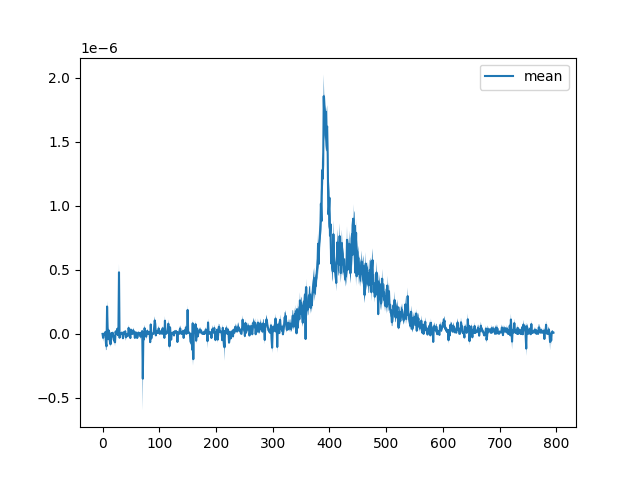

In [59]:
fig,ax=plt.subplots(1,1)
# ax.plot(datsum,label='sum')
# ax.fill_between(np.arange(len(datsum)),datsum-uncertainty_sum,datsum+uncertainty_sum)
ax.plot(datmean,label='mean')
ax.fill_between(np.arange(len(datmean)),datmean-standard_error_mean,datmean+standard_error_mean)
# ax.plot(V_on_std,label = 'std')
# ax.plot(np.mean(data_matrix,axis=0),label='mean')
# ax.plot(standard_error_mean,label='error')
# ax.plot(np.sum(data_matrix,axis=0),label='sum')
# ax.plot(uncertainty_sum,label='error')
ax.legend()

In [8]:
calculate_error_from_data(proc.proc['axis_svls']['on'])

/lscratch/amke/tmp/ipykernel_3195156/3883306039.py:29: RuntimeWarning: divide by zero encountered in divide
  V_on_mean = np.nansum(data_matrix, axis=1) / np.nansum(data_matrix > 0, axis=1)
/lscratch/amke/tmp/ipykernel_3195156/3883306039.py:35: RuntimeWarning: invalid value encountered in multiply
  variance_signal = p_on * (V_on_std**2 + V_on_mean**2)


(array([           nan,            nan, 5.29078748e-08, ...,
                   nan,            nan, 4.55329987e-08]),
 array([           nan,            nan, 4.21146683e-05, ...,
                   nan,            nan, 3.62442670e-05]))

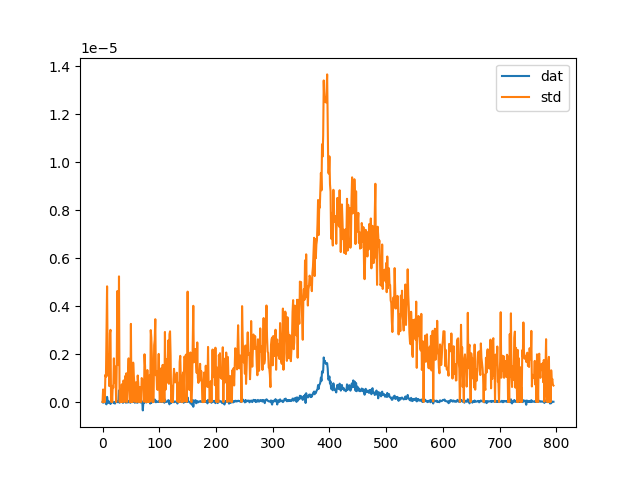

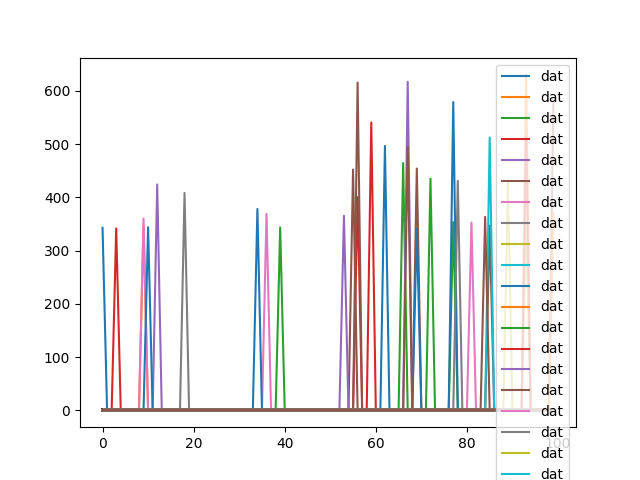

In [63]:
fig,ax=plt.subplots(1,1)
ax.plot(np.nanmean(proc.proc['axis_svls']['on'],axis=0),label='dat')
ax.plot(np.nanstd(proc.proc['axis_svls']['on'],axis=0),label='std')

# ax.plot((1/np.sqrt(proc.axis_svls_on_std.shape[0]**2))*np.sqrt(np.nansum(proc.axis_svls_on_std**2,axis=1)),label='std 2')
ax.legend()
# ax.plot((1/np.sqrt(proc.axis_svls_on_std.shape[0]))*np.sqrt(np.nansum(proc.axis_svls_on_std**2,axis=1)))

fig,ax=plt.subplots(1,1)
ax.plot((axis_svls[1500:1600,:]),label='dat')

# ax.plot((1/np.sqrt(proc.axis_svls_on_std.shape[0]**2))*np.sqrt(np.nansum(proc.axis_svls_on_std**2,axis=1)),label='std 2')
ax.legend()
# ax.plot((1/np.sqrt(proc.axis_svls_on_std.shape[0]))*np.sqrt(np.nansum(proc.axis_svls_on_std**2,axis=1)))


In [ ]:

PFY_O_off_std = np.sqrt(np.nansum(OK_mono['axis_svls_off_std'][:]**2, axis=1))

(44, 796)

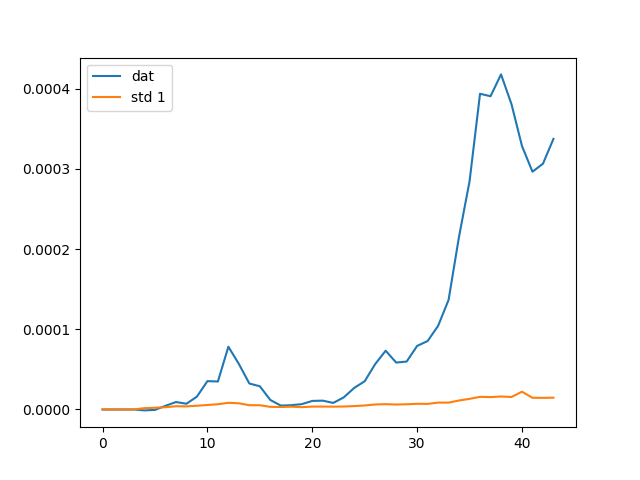

In [10]:
fig,ax=plt.subplots(1,1)
ax.plot(np.nansum(proc.axis_svls_on_mean,axis=1),label='dat')
ax.plot(np.sqrt(np.nansum(proc.axis_svls_on_std**2, axis=1)),label='std 1')
# ax.pcolor(proc.axis_svls_on_mean)
# ax.plot((1/np.sqrt(proc.axis_svls_on_std.shape[0]**2))*np.sqrt(np.nansum(proc.axis_svls_on_std**2,axis=1)),label='std 2')
ax.legend()
# ax.plot((1/np.sqrt(proc.axis_svls_on_std.shape[0]))*np.sqrt(np.nansum(proc.axis_svls_on_std**2,axis=1)))

# fig,ax=plt.subplots(1,1)
# # ax.plot(np.nanmean(proc.axis_svls_on_mean,axis=1),label='dat')
# # ax.plot(np.nanmean(proc.axis_svls_on_std,axis=1),label='std 1')
# ax.pcolor(proc.axis_svls_on_std)

In [ ]:

import scipy.stats as st
expected_count = st.mode(proc.data.integrating.axis_svls.count, keepdims=False)[0]
evc = getattr(proc.data.integrating.axis_svls, 'eventcodes')
onmask = np.asarray([evc[:,proc.data.yaml['evc'][True]]/expected_count>0.5]).squeeze()#(evc[:,272]==1)
offmask = np.asarray([evc[:,proc.data.yaml['evc'][False]]/expected_count>0.5]).squeeze()#(evc[:,272]==1)#(evc[:,273]==1)

axis_svls=proc.data.integrating.axis_svls.full_area
mono=proc.data.integrating.axis_svls.mono

In [ ]:
scanvar_bin, tmp_sum, tmp_mean, tmp_std, counts = bin_data(norm,scanvar,bins=self.data.yaml['bins'],scantype='fly')


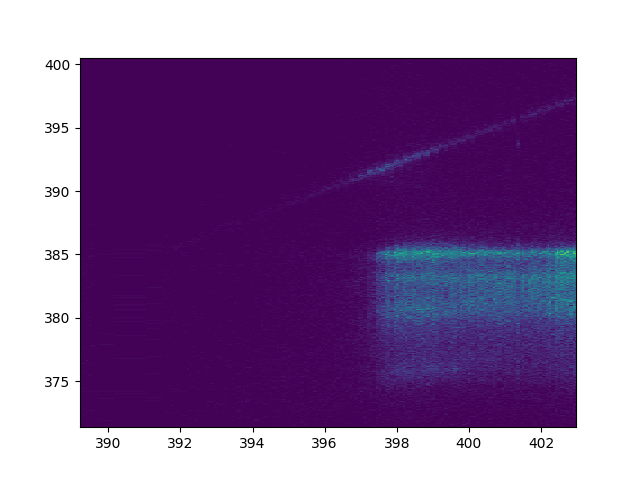

In [37]:
fig,ax=plt.subplots(1,1)
ax.pcolor(proc.scanvar, (-0.0366449869656799)*np.arange(proc.axis_svls_mean.shape[1])+400.5108021860192,(proc.axis_svls_mean).T)
#(-0.0366449869656799, 400.5108021860192)


/sdf/home/a/amke/DataAcceleratorChemRIXS/src/chemrixs/average.py:374: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w--" (-> color='w'). The keyword argument will take precedence.
  plt.plot(x_line, y_center, 'w--', lw=1.5, color='k',label='initial guess')
/sdf/home/a/amke/DataAcceleratorChemRIXS/src/chemrixs/average.py:375: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w-" (-> color='w'). The keyword argument will take precedence.
  plt.plot(x_line, y_top,    'w-',  lw=1.0, alpha=0.8,color='k')
/sdf/home/a/amke/DataAcceleratorChemRIXS/src/chemrixs/average.py:376: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w-" (-> color='w'). The keyword argument will take precedence.
  plt.plot(x_line, y_bot,    'w-',  lw=1.0, alpha=0.8,color='k')


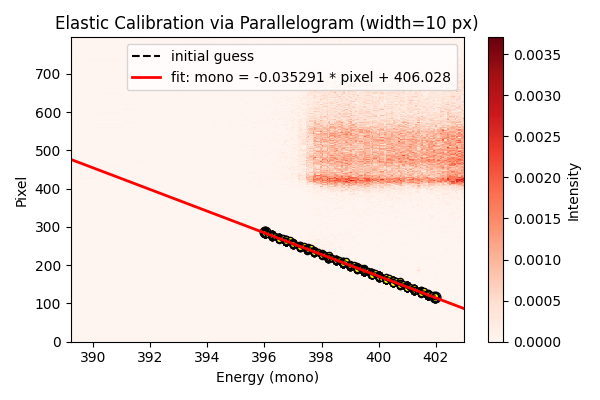

(array([406.02800979, 405.99271878, 405.95742776, 405.92213675,
        405.88684573, 405.85155472, 405.8162637 , 405.78097268,
        405.74568167, 405.71039065, 405.67509964, 405.63980862,
        405.6045176 , 405.56922659, 405.53393557, 405.49864456,
        405.46335354, 405.42806252, 405.39277151, 405.35748049,
        405.32218948, 405.28689846, 405.25160745, 405.21631643,
        405.18102541, 405.1457344 , 405.11044338, 405.07515237,
        405.03986135, 405.00457033, 404.96927932, 404.9339883 ,
        404.89869729, 404.86340627, 404.82811525, 404.79282424,
        404.75753322, 404.72224221, 404.68695119, 404.65166018,
        404.61636916, 404.58107814, 404.54578713, 404.51049611,
        404.4752051 , 404.43991408, 404.40462306, 404.36933205,
        404.33404103, 404.29875002, 404.263459  , 404.22816798,
        404.19287697, 404.15758595, 404.12229494, 404.08700392,
        404.05171291, 404.01642189, 403.98113087, 403.94583986,
        403.91054884, 403.87525783, 403.

In [3]:
avg.emi_calibration([396,286], [402,116],
                                    width_pixels=10,
                                    plot_on=True,
                                    use='')

In [24]:
calibrated_axis, (a, b), details = elastic_calibrate_from_two_points(
                                    avg.average['scanvar'],
                                    avg.average['axis_svls_mean'],
                                    [395,314], [401,142],
                                    width_pixels=10,
                                    plot_on=True
                                 )

NameError: name 'elastic_calibrate_from_two_points' is not defined

In [11]:
(a,b)

(-0.0366449869656799, 400.5108021860192)

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(15,3))
ax.scatter(np.arange(len(data.integrating.axis_svls.mono))[data.integrating.axis_svls.eventcodes[:,272]==1],data.integrating.axis_svls.mono[data.integrating.axis_svls.eventcodes[:,272]==1],color='r',s=2,label='laser on')
ax.scatter(np.arange(len(data.integrating.axis_svls.mono))[data.integrating.axis_svls.eventcodes[:,273]==1],data.integrating.axis_svls.mono[data.integrating.axis_svls.eventcodes[:,273]==1],color='k',s=2,label='laser off')
ax.legend()
ax.set_xlim([0,len(data.integrating.axis_svls.mono)])
# fig.savefig('figs/mono_move_onoff.png',dpi=200,bbox_inches='tight')


In [ ]:
for run in runs:
    fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
    red = Reduced(fname,bgname,fyaml,bgyaml, save=True)



avg=avg_data(runs,proc_folder)

In [ ]:
red.data.integrating.axis_svls.mono.max()

In [ ]:
fig,ax=plt.subplots()
ax.plot(np.nansum(red.data.integrating.axis_svls.full_area,axis=0),'k',label='data')
ax.plot(np.nansum(red.bg.integrating.axis_svls.full_area,axis=0),'r',alpha=0.5,label='background')
ax.legend()
# ax.plot(np.nansum(red.proc,axis=0),'k')
# ax.plot(np.nansum(red.proc.svls,axis=0),'r')

In [ ]:
fig,ax=plt.subplots(1,1)
ax.plot(red.scanvar_on,np.sum(red.axis_svls_on_mean,1)-np.sum(red.axis_svls_off_mean,1))
ax.plot(red.scanvar_off,np.sum(red.axis_svls_off_mean,1))
# ax.set_xlim([red.scanvar_on.min(),red.scanvar_on.max()])

In [ ]:
fig,ax=plt.subplots(1,3,figsize=(9,3),sharex=True,sharey=True)
ax[0].pcolor(avg['scanvar_on'],np.arange(avg['axis_svls_on_sum'].shape[1]),avg['axis_svls_on_sum'].T,cmap='terrain_r',vmin=0,vmax=np.nanmax(avg['axis_svls_on_sum']))
ax[1].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),avg['axis_svls_off_sum'].T,cmap='terrain_r',vmin=0,vmax=np.nanmax(avg['axis_svls_off_sum']))
ddat=np.nanmax(np.abs(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']))
ax[2].pcolor(avg['scanvar_on'],np.arange(avg['axis_svls_on_sum'].shape[1]),(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']).T,cmap='RdBu')
ax[0].set_xlim([avg['scanvar_off'].min(),avg['scanvar_off'].max()])

In [ ]:
emi_calib = [0.06521910251275982, 534.809958523687]
points=[[569.5,533],[573.2,589]]
mono_inc = 530

# if emi_calib == []:
#     if data.runinfo == 'mono':
emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
            dat=avg['axis_svls_sum'], 
            mono = avg['scanvar'], 
            calib=emi_calib, 
                points = points)
#     else:
#         print('need mono scan to calibrate using emission axis')
# else:
#     emi,calib =pixel2emi(np.arange(avg['axis_svls_sum'].shape[1]), mono=[],
#                     dat=avg['axis_svls_sum'], 
#                     calib=emi_calib) 
                    
# if data.runinfo == 'mono':
mono, E_trans_on, data_trans_on=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
mono, E_trans_off, data_trans_off=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
# else:
#     E_trans = mono_inc - emi

fig,ax=plt.subplots(1,3, sharex=True, sharey=True)
ax[0].pcolor(mono,E_trans_on, data_trans_on.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_on))
ax[1].pcolor(mono,E_trans_off, data_trans_off.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_off))
ax[2].pcolor(mono,E_trans_on, (data_trans_on-data_trans_off).T,vmin=np.min((data_trans_on-data_trans_off)),cmap='terrain_r',vmax=np.max((data_trans_on-data_trans_off)))

In [ ]:
emi_calib = [0.06521910251275982, 534.809958523687]
points=[[569.5,533],[573.2,589]]
mono_inc = 530

if emi_calib == []:
    if data.scantype == 'mono':
        emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
                    avg['axis_svls_on_sum'], 
                    mono = avg['scanvar_on'], 
                    calib=emi_calib, 
                    points = points)
    else:
        print('need mono scan to calibrate using emission axis')
else:
    emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
                    avg['axis_svls_on_sum'], 
                    calib=emi_calib) 
                    
if data.scantype == 'mono':
    mono, E_trans_on, data_trans_on=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
    mono, E_trans_off, data_trans_off=emi2ET(avg['scanvar_off'],emi,avg['axis_svls_off_sum'],step=0.1)
else:
    E_trans = mono_inc - emi

fig,ax=plt.subplots(1,3, sharex=True, sharey=True)
ax[0].pcolor(mono,E_trans_on, data_trans_on.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_on))
ax[1].pcolor(mono,E_trans_off, data_trans_off.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_off))
ax[2].pcolor(mono,E_trans_on, (data_trans_on-data_trans_off).T,vmin=np.min((data_trans_on-data_trans_off)),cmap='terrain_r',vmax=np.max((data_trans_on-data_trans_off)))

In [ ]:
fig,ax=plt.subplots(1,3)
ax[0].pcolor(avg['scanvar_on'],emi,avg['axis_svls_on_sum'].T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_on_sum']))
ax[1].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),avg['axis_svls_off_sum'].T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_off_sum']))
ax[2].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']).T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']))



In [ ]:

fig,ax=plt.subplots(1,3)
ax[0].pcolor(red.scanvar_on,np.arange(red.axis_svls_on_mean.shape[1]),red.axis_svls_on_mean.T,cmap='terrain_r',vmin=-0,vmax=np.max(red.axis_svls_off_mean))
ax[1].pcolor(red.scanvar_off,np.arange(red.axis_svls_off_mean.shape[1]),red.axis_svls_off_mean.T,cmap='terrain_r',vmin=0,vmax=np.max(red.axis_svls_off_mean))
ax[2].pcolor(red.scanvar_on,np.arange(red.axis_svls_on_mean.shape[1]),red.axis_svls_on_mean.T-red.axis_svls_off_mean.T,cmap='terrain_r',vmin=-0,vmax=np.max(red.axis_svls_on_mean-red.axis_svls_off_mean))


In [ ]:
data.singleshot.fim_0.full_area
bg_roi=[0,50]
bg = np.mean(data.singleshot.fim_0.full_area[...,bg_roi[0]:bg_roi[1]],axis= -1)
bgf = data.singleshot.fim_0.full_area - bg[...,np.newaxis]

In [ ]:
fim_roi=[60,70]

fim_proc =subtract_bg(data.singleshot.fim_0.full_area,[0,50])
fim_wf_avs = np.nanmean(fim_proc,axis = 0)
# fim = np.sum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = (1,2))

# fim = np.nansum(fim_proc[:,:,fim_roi[0]:fim_roi[1]],axis = (1,2))

fim_sum_all = np.nansum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = 2)

In [6]:
# run=76
# fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
# test = h5py.File(fname, 'r')
#run=142
#fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
run=84
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
test1 = h5py.File(fname, 'r')
test1['intg']['axis_svls'].keys()
# test1['scan']['lxt_ttc']

<KeysViewHDF5 ['c_piranha_sum_full_area', 'count', 'crix_w8_sum_base_0', 'crix_w8_sum_base_1', 'crix_w8_sum_base_2', 'crix_w8_sum_base_3', 'crix_w8_sum_base_4', 'crix_w8_sum_base_5', 'crix_w8_sum_base_6', 'crix_w8_sum_base_7', 'crix_w8_sum_base_all', 'crix_w8_sum_integral_0', 'crix_w8_sum_integral_1', 'crix_w8_sum_integral_2', 'crix_w8_sum_integral_3', 'crix_w8_sum_integral_4', 'crix_w8_sum_integral_5', 'crix_w8_sum_integral_6', 'crix_w8_sum_integral_7', 'crix_w8_sum_integral_all', 'crix_w8_sum_intensity', 'crix_w8_sum_itrigCount', 'crix_w8_sum_posX', 'crix_w8_sum_posY', 'crix_w8_sum_ptrigCount', 'det_crix_w8_sum_full_area', 'det_crix_w8_sum_wfintegrate', 'det_rix_fim0_sum_full_area', 'det_rix_fim0_sum_wfintegrate', 'det_rix_fim1_sum_full_area', 'det_rix_fim1_sum_wfintegrate', 'droplet_dense_curve_corr_corrected_image', 'droplet_dense_curve_corr_pj_ax_1_data', 'droplet_nDroplets', 'droplet_nDroplets_all', 'gmd_sum_RMS_E1', 'gmd_sum_RMS_E1_sevr', 'gmd_sum_milliJoulesPerPulse', 'gmd_sum_

In [ ]:
premirror = get_premirror_pitch(red.data.epics['MONO_premirror_pitch'][:])
hrencoder = red.data.integrating.andor_vls.mono_encoder
hr_pitch = hrencoder_to_pitch(hrencoder, red.data.yaml['mono_calib'])
hr_energy = mono_energy(hr_pitch,premirror)
hr_energy

In [ ]:
testfile = h5py.File('testsave.h5','w')
keys = vars(red)
avg = {}
for key in keys:
    avg[key] = np.zeros(testfile[key].shape)

for dat in keys:
    if 'on' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])
    elif 'off' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])


testfile.close()

In [ ]:
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
with h5py.File(fname) as tmp:
    h5dump(tmp)


In [4]:

import dask.array as da
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'
exp = 'rix101331225'
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run0061.h5'


with h5py.File(fname,'r') as file:
    print(file['intg']['axis_svls'].keys())
    test=da.from_array(file['intg']['axis_svls']['det_crix_w8_sum_full_area'], chunks = 'auto')
    # ax.plot(np.nanmean(file['intg']['axis_svls']['curve_corr_corrected_image'],axis=0))
    # fh = h5py.File(fname, 'r')
    test_ims_thresh = file['intg/axis_svls/curve_corr_corrected_image'][:20,:][...]
    test_los_thresh = file['intg/axis_svls/curve_corr_pj_ax_1_data'][:,:][...]
plt.figure()
plt.subplot(211)
plt.plot(np.nanmean(test_los_thresh,axis =0),label = 'curve_corr_pj_ax_1_data')
plt.legend()
plt.subplot(212)
plt.plot(np.nanmean(test_ims_thresh,axis =(0,2)),label = 'lineout from curve_corr_corrected_image')
plt.xlabel('pixel')
# Plt.legend()
plt.show()

<KeysViewHDF5 ['count', 'crix_w8_sum_base_0', 'crix_w8_sum_base_1', 'crix_w8_sum_base_2', 'crix_w8_sum_base_3', 'crix_w8_sum_base_4', 'crix_w8_sum_base_5', 'crix_w8_sum_base_6', 'crix_w8_sum_base_7', 'crix_w8_sum_base_all', 'crix_w8_sum_integral_0', 'crix_w8_sum_integral_1', 'crix_w8_sum_integral_2', 'crix_w8_sum_integral_3', 'crix_w8_sum_integral_4', 'crix_w8_sum_integral_5', 'crix_w8_sum_integral_6', 'crix_w8_sum_integral_7', 'crix_w8_sum_integral_all', 'crix_w8_sum_intensity', 'crix_w8_sum_itrigCount', 'crix_w8_sum_posX', 'crix_w8_sum_posY', 'crix_w8_sum_ptrigCount', 'det_crix_w8_sum_full_area', 'det_crix_w8_sum_wfintegrate', 'det_rix_fim0_sum_full_area', 'det_rix_fim0_sum_wfintegrate', 'det_rix_fim1_sum_full_area', 'det_rix_fim1_sum_wfintegrate', 'droplet_dense_curve_corr_corrected_image', 'droplet_nDroplets', 'droplet_nDroplets_all', 'gmd_sum_RMS_E1', 'gmd_sum_RMS_E1_sevr', 'gmd_sum_milliJoulesPerPulse', 'gmd_sum_milliJoulesPerPulse_sevr', 'lightStatus_sum_laser', 'lightStatus_sum

KeyError: "Unable to synchronously open object (object 'curve_corr_corrected_image' doesn't exist)"

In [10]:
test_ims_thresh.sum()

0.0

In [25]:
run=9
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
with h5py.File(fname) as tmp:
    print(tmp.keys())

<KeysViewHDF5 ['crix_w8', 'epics_archiver', 'lightStatus', 'mono_hrencoder', 'rix_fim0', 'rix_fim1', 'scan', 'timestamp', 'timing']>


In [9]:
run=23
fname = f'./avg/Run0022to0023.h5'
with h5py.File(fname) as tmp:
    print(tmp['E_trans_off'][:])

[-20.744991   -20.54499    -20.34499    -20.14499    -19.94499
 -19.744991   -19.54499    -19.34499    -19.14499    -18.94499
 -18.744991   -18.54499    -18.34499    -18.14499    -17.94499
 -17.744991   -17.54499    -17.34499    -17.14499    -16.94499
 -16.744991   -16.54499    -16.34499    -16.14499    -15.944991
 -15.74499    -15.544991   -15.344991   -15.144991   -14.944991
 -14.74499    -14.544991   -14.344991   -14.144991   -13.944991
 -13.74499    -13.544991   -13.344991   -13.144991   -12.944991
 -12.74499    -12.544991   -12.344991   -12.144991   -11.944991
 -11.74499    -11.544991   -11.344991   -11.144991   -10.944991
 -10.74499    -10.544991   -10.344991   -10.144991    -9.944991
  -9.74499     -9.544991    -9.344991    -9.144991    -8.944991
  -8.74499     -8.544991    -8.344991    -8.144991    -7.9449906
  -7.744991    -7.5449905   -7.3449907   -7.144991    -6.9449906
  -6.744991    -6.5449905   -6.3449907   -6.144991    -5.9449906
  -5.744991    -5.5449905   -5.3449907   

In [ ]:

# def avg_data(runs : list, proc_folder : str = '',proc_path : str = ''):
runs=[23,26]
proc_folder = './proc/Run'
avg = {}
with h5py.File(proc_folder+f'{runs[0]:04d}.h5','r') as tmp:
    keys = list(tmp.keys())
    if 'counts_on' in keys:
        counts_on = np.zeros(tmp['counts_on'].shape)
        counts_off = np.zeros(tmp['counts_off'].shape)
        laser = True
    else:
        counts = np.zeros(tmp['counts'].shape)
        laser = False

    # print(keys)
    for key in keys:
        avg[key] = np.zeros(tmp[key].shape)

i=0
for run in runs:
    i=i+1
    file = proc_folder+f'{run:04d}.h5'
    # FIXME:     
    with h5py.File(file,'r') as f:
        print(np.asarray(f['scanvar_off']))
        if laser:
            count_on = np.asarray(f['counts_on'])
            count_off = np.asarray(f['counts_off'])
            print(count_off)
            laser = True
        else:
            count = np.asarray(f['counts'])

        for key in keys:
            if laser:
                if 'on' in key:
                    count = count_on
                elif 'off' in key:
                    count = count_off
            else:
                count = count

            if avg[key].shape==f[key].shape:
                if len(avg[key].shape) == 1:
                    avg[key] = avg[key] + np.asarray(f[key])*count
                else:
                    avg[key] = avg[key] + np.asarray(f[key])*count[:,np.newaxis]
                # print(f[key])
            else:
                print(f'shape0 {avg[key].shape} shape1 {f[key].shape}')
                #FIXME: Here implement stuff for stitching
                print(f'Run {run} {key} shapes do not match')
    if laser:
        counts_on = counts_on + count_on
        counts_off = counts_off + count_off

    else:
        counts = counts + count
        
for key in keys:
    if laser:
        if 'on' in key:
            if len(avg[key].shape) == 1:
                avg[key] = avg[key]/counts_on
            else:
                avg[key] = avg[key]/counts_on[:,np.newaxis]
        elif 'off' in key:
            if len(avg[key].shape) == 1:
                avg[key] = avg[key]/counts_off
            else:
                avg[key] = avg[key]/counts_off[:,np.newaxis]
    else:
        if len(avg[key].shape) == 1:
            avg[key] = avg[key]/counts
        else:
            avg[key] = avg[key]/counts[:,np.newaxis]
    # return avg
    

[521.11536 521.3461  521.5769  521.8077  522.03845 522.2692  522.5
 522.7308  522.96155 523.1923  523.4231  523.6539  523.88464 524.11536
 524.3461  524.5769  524.8077  525.03845 525.2692  525.5     525.7308
 525.96155 526.1923  526.4231  526.6539  526.88464 527.11536 527.3461
 527.5769  527.8077  528.03845 528.2692  528.5     528.7308  528.96155
 529.1923  529.4231  529.6539  529.88464]
[249. 144. 143. 147. 153. 168. 130. 161. 139. 150. 148. 156. 146. 139.
 150. 145. 148. 141. 158. 138. 151. 144. 141. 140. 148. 140. 145. 148.
 143. 143. 142. 146. 118.  72. 125. 146. 136. 150. 142.]
[521.11536 521.3461  521.5769  521.8077  522.03845 522.2692  522.5
 522.7308  522.96155 523.1923  523.4231  523.6539  523.88464 524.11536
 524.3461  524.5769  524.8077  525.03845 525.2692  525.5     525.7308
 525.96155 526.1923  526.4231  526.6539  526.88464 527.11536 527.3461
 527.5769  527.8077  528.03845 528.2692  528.5     528.7308  528.96155
 529.1923  529.4231  529.6539  529.88464]
[160. 140. 144. 158

In [19]:
run=23
file = proc_folder+f'{run:04d}.h5'
# FIXME:     
f1= h5py.File(file,'r')

run=26
file = proc_folder+f'{run:04d}.h5'
# FIXME:     
f2= h5py.File(file,'r')

x1 =np.asarray(f1['scanvar_off'])
c1 =np.asarray(f1['counts_off'])
x2 =np.asarray(f2['scanvar_off'])
c2 =np.asarray(f2['counts_off'])

(x1*c1+x2*c2)/(c1+c2)
c1+c2

array([409., 284., 287., 305., 298., 320., 277., 310., 286., 306., 292.,
       307., 291., 275., 304., 292., 293., 295., 298., 279., 305., 285.,
       280., 292., 285., 290., 287., 294., 282., 295., 274., 299., 256.,
       218., 262., 293., 281., 295., 287.], dtype=float32)

array([521.11536, 521.3462 , 521.5769 , 521.8077 , 522.0385 , 522.2692 ,
       522.5    , 522.7308 , 522.96155, 523.1923 , 523.42303, 523.6539 ,
       523.88464, 524.11536, 524.3461 , 524.5769 , 524.8077 , 525.03845,
       525.2692 , 525.5    , 525.7307 , 525.9615 , 526.1923 , 526.4231 ,
       526.6538 , 526.88464, 527.11536, 527.34607, 527.5769 , 527.8077 ,
       528.03845, 528.2692 , 528.5    , 528.7308 , 528.9616 , 529.1923 ,
       529.4231 , 529.6539 , 529.88464], dtype=float32)

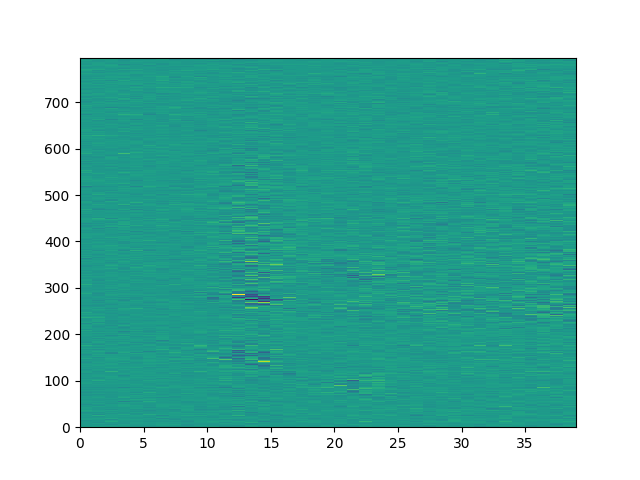

In [25]:
fig,ax=plt.subplots(1,1)
ax.pcolor(avg['axis_svls_on_mean'].T-avg['axis_svls_off_mean'].T)